<a href="https://colab.research.google.com/github/Afila1996/RAE2822_Airfoil_Examples/blob/main/FNO_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install neuraloperator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 3.5 MB/s eta 0:00:00


In [34]:
import torch
import torch.nn as nn
from neuralop.models import FNO
from matplotlib import pyplot as plt

##RAE2822 dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import numpy as np

data_dir = "/content/drive/MyDrive/RAE2822_data"

db_path = os.path.join(data_dir, "db_random.npy")
airfoil_path = os.path.join(data_dir, "airfoil.npy")

db = np.load(db_path, allow_pickle=True).item()
airfoil = np.load(airfoil_path)



In [6]:
for k, v in db.items():
    if hasattr(v, "shape"):
        print(f"{k}: {v.shape}")

idx: (1007,)
Alpha: (1007,)
Vinf: (1007,)
Cl: (1007,)
Cd: (1007,)
Cm: (1007,)
Cp: (1007, 691)
Cf: (1007, 691)
Xcoordinate: (1007, 27499)
Ycoordinate: (1007, 27499)
Pressure: (1007, 27499)
Mach: (1007, 27499)
Vmag: (1007, 27499)
Temperature: (1007, 27499)
Vx: (1007, 27499)
Vy: (1007, 27499)
Airfoil: (691, 2)


#interpolation

In [7]:
def freestream_temperature(x, y, temperature, far_percentile=99):

    xc = np.median(x)
    yc = np.median(y)

    r = np.sqrt((x - xc)**2 + (y - yc)**2)

    r_threshold = np.percentile(r, far_percentile)
    far = r >= r_threshold

    T_inf = np.median(temperature[far])

    return T_inf


In [8]:
gamma = 1.4
R = 287.0

N = len(db["idx"])

machinf = np.zeros(N)

i=0

for i in range(N):

    x = db["Xcoordinate"][i]
    y = db["Ycoordinate"][i]
    T = db["Temperature"][i]
    Vinf = db["Vinf"][i]


    T_inf = freestream_temperature(x, y, T)

    a_inf = np.sqrt(gamma * R * T_inf)

    machinf[i] = Vinf / a_inf


In [9]:
def normalize_geometry(x, y, machinf, M_ref):


    s = machinf/ M_ref


    x_lo = np.quantile(x, 0.01)


    y0 = np.median(y)

    # shift + Mach scaling
    x_scaled = (x - x_lo) * s
    y_scaled = (y - y0) * s

    x_le = np.quantile(x_scaled, 0.01)
    x_tr = np.quantile(x_scaled, 0.99)

    chord = x_tr - x_le


    xN = x_scaled / chord
    yN = y_scaled / chord

    return xN, yN


In [10]:
# reference Mach
M_ref = np.mean(machinf)

xN_all = []
yN_all = []

i=0

for i in range(N):

    x = db["Xcoordinate"][i]
    y = db["Ycoordinate"][i]
    xN, yN = normalize_geometry(x, y, machinf[i], M_ref)

    xN_all.append(xN)
    yN_all.append(yN)


In [11]:
import numpy as np
import torch
from scipy.interpolate import griddata


H, W = 128, 128

x_lin = np.linspace(db["Xcoordinate"].min(), db["Xcoordinate"].max(), W)
y_lin = np.linspace(db["Ycoordinate"].min(), db["Ycoordinate"].max(), H)

Xg, Yg = np.meshgrid(x_lin, y_lin)

In [12]:
from scipy.interpolate import griddata


def interpolate_to_grid(x, y, values, Xg, Yg, method='cubic'):

    pts = np.column_stack([x, y])

    Z = griddata(pts, values, (Xg, Yg), method=method)

    # fill holes
    if np.isnan(Z).any():
        Z_nn = griddata(pts, values, (Xg, Yg), method='nearest')
        Z = np.where(np.isnan(Z), Z_nn, Z)

    return Z.astype(np.float32)


In [13]:
from matplotlib.path import Path
def airfoil_mask(Airfoil, Xg, Yg):


    airfoil_path = Path(airfoil)


    grid_points = np.column_stack((Xg.ravel(), Yg.ravel()))


    inside = airfoil_path.contains_points(grid_points)

    mask = inside.reshape(Xg.shape)

    return mask.astype(np.float32)


airfoil_mask = airfoil_mask(airfoil, Xg, Yg)

In [14]:
def interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg):

    # interpolate outputs
    u_g = interpolate_to_grid(xN, yN, u, Xg, Yg)
    v_g = interpolate_to_grid(xN, yN, v, Xg, Yg)
    p_g = interpolate_to_grid(xN, yN, p, Xg, Yg)


    airfoil_mask_binary = airfoil_mask.astype(bool)
    p_g[airfoil_mask_binary] = 0.0
    u_g[airfoil_mask_binary] = 0.0
    v_g[airfoil_mask_binary] = 0.0

    #coordinate channels
    xmin, xmax = Xg.min(), Xg.max()
    ymin, ymax = Yg.min(), Yg.max()

    xchan = 2*(Xg-xmin)/(xmax-xmin)-1
    ychan = 2*(Yg-ymin)/(ymax-ymin)-1


    mach_chan = np.full_like(xchan, mach_inf)
    aoa_chan = np.full_like(xchan, aoa)

    #build input tensor
    X_in = np.stack([xchan, ychan, airfoil_mask, mach_chan, aoa_chan], axis=0)

    # build output tensor
    Y_out = np.stack([p_g, u_g, v_g], axis=0)

    return X_in.astype(np.float32), Y_out.astype(np.float32)


In [59]:
# dataset_inputs = []
# dataset_outputs = []

# for i in range(N):

#     xN = xN_all[i]
#     yN = yN_all[i]

#     u = db["Vx"][i]
#     v = db["Vy"][i]
#     p = db["Pressure"][i]


#     mach_inf = machinf[i]
#     aoa = db["Alpha"][i]

#     X_in, Y_out = interpolation(xN, yN, u, v, p, mach_inf, aoa, airfoil_mask, Xg, Yg)

#     dataset_inputs.append(X_in)
#     dataset_outputs.append(Y_out)


In [16]:
import pickle

load_path = "/content/drive/MyDrive/RAE2822_data/dataset.pkl"

with open(load_path, 'rb') as f:
    data = pickle.load(f)

dataset_inputs  = data['dataset_inputs']
dataset_outputs = data['dataset_outputs']


print(f"Inputs shape:  {dataset_inputs.shape}")   # (1007, 5, 128, 128)
print(f"Outputs shape: {dataset_outputs.shape}")  # (1007, 3, 128, 128)

Inputs shape:  (1007, 5, 128, 128)
Outputs shape: (1007, 3, 128, 128)


In [17]:
mach_mean = dataset_inputs[:, 3].mean()
mach_std = dataset_inputs[:, 3].std()
dataset_inputs[:, 3, :, :] = (dataset_inputs[:, 3, :, :] - mach_mean) / (mach_std + 1e-8)

aoa_mean = dataset_inputs[:, 4].mean()
aoa_std = dataset_inputs[:, 4].std()
dataset_inputs[:, 4, :, :] = (dataset_inputs[:, 4, :, :] - aoa_mean) / (aoa_std + 1e-8)



mask = dataset_inputs[0, 2, :, :]
valid_region = (mask == 0)

for ch in range(3):
    channel_name = ['Pressure', 'U-velocity', 'V-velocity'][ch]
    channel_data = dataset_outputs[:, ch, :, :]


    valid_values = channel_data[:, valid_region]

    mean = valid_values.mean()
    std = valid_values.std()

    dataset_outputs[:, ch, :, :] = (channel_data - mean) / (std + 1e-8)


    for i in range(len(dataset_outputs)):
        dataset_outputs[i, ch][mask == 1] = 0.0



In [18]:
import os
import pandas as pd
from torchvision.io import decode_image

In [19]:
from sklearn.model_selection import train_test_split


X_tv, X_test, y_tv, y_test = train_test_split(dataset_inputs, dataset_outputs, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape[0]}")
print(f"Validation set: {X_val.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Train set: 644
Validation set: 161
Test set: 202


In [27]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val   = torch.tensor(y_val, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

/tmp/ipython-input-343/3833134942.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = FNO(n_modes=(20, 20), hidden_channels=64,
            in_channels=X_train.shape[1], out_channels=y_train.shape[1], n_layers=4).to(device)

In [30]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=8, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=8)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=8)

In [42]:
import torch.optim as optim

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

In [33]:
for epoch in range(20):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += loss_fn(pred, yb).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch:02d} | train {train_loss:.6f} | val {val_loss:.6f}")

Epoch 00 | train 0.559789 | val 0.123606
Epoch 01 | train 0.099159 | val 0.060927
Epoch 02 | train 0.064910 | val 0.048474
Epoch 03 | train 0.054409 | val 0.055820
Epoch 04 | train 0.044121 | val 0.036427
Epoch 05 | train 0.043089 | val 0.037279
Epoch 06 | train 0.042561 | val 0.037094
Epoch 07 | train 0.035404 | val 0.031085
Epoch 08 | train 0.034422 | val 0.042309
Epoch 09 | train 0.034911 | val 0.019471
Epoch 10 | train 0.026173 | val 0.017993
Epoch 11 | train 0.028342 | val 0.020411
Epoch 12 | train 0.033968 | val 0.020320
Epoch 13 | train 0.026103 | val 0.020588
Epoch 14 | train 0.024636 | val 0.035299
Epoch 15 | train 0.025344 | val 0.015655
Epoch 16 | train 0.019642 | val 0.024457
Epoch 17 | train 0.017956 | val 0.011661
Epoch 18 | train 0.017569 | val 0.011037
Epoch 19 | train 0.015308 | val 0.007751


In [43]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb)

        all_preds.append(pred.cpu())
        all_targets.append(yb)

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)



In [61]:
def r2_score_torch(y_true, y_pred):
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    ss_res = torch.sum((y_true_flat - y_pred_flat) ** 2)
    ss_tot = torch.sum((y_true_flat - torch.mean(y_true_flat)) ** 2)

    return 1 - ss_res / ss_tot

for c, name in enumerate(["Pressure", "Vx", "Vy"]):
    r2_c = r2_score_torch(all_targets[:,c], all_preds[:,c])
    print(f"R² for {name}: {r2_c.item():.4f}")

R² for Pressure: 0.9828
R² for Vx: 0.9902
R² for Vy: 0.9972


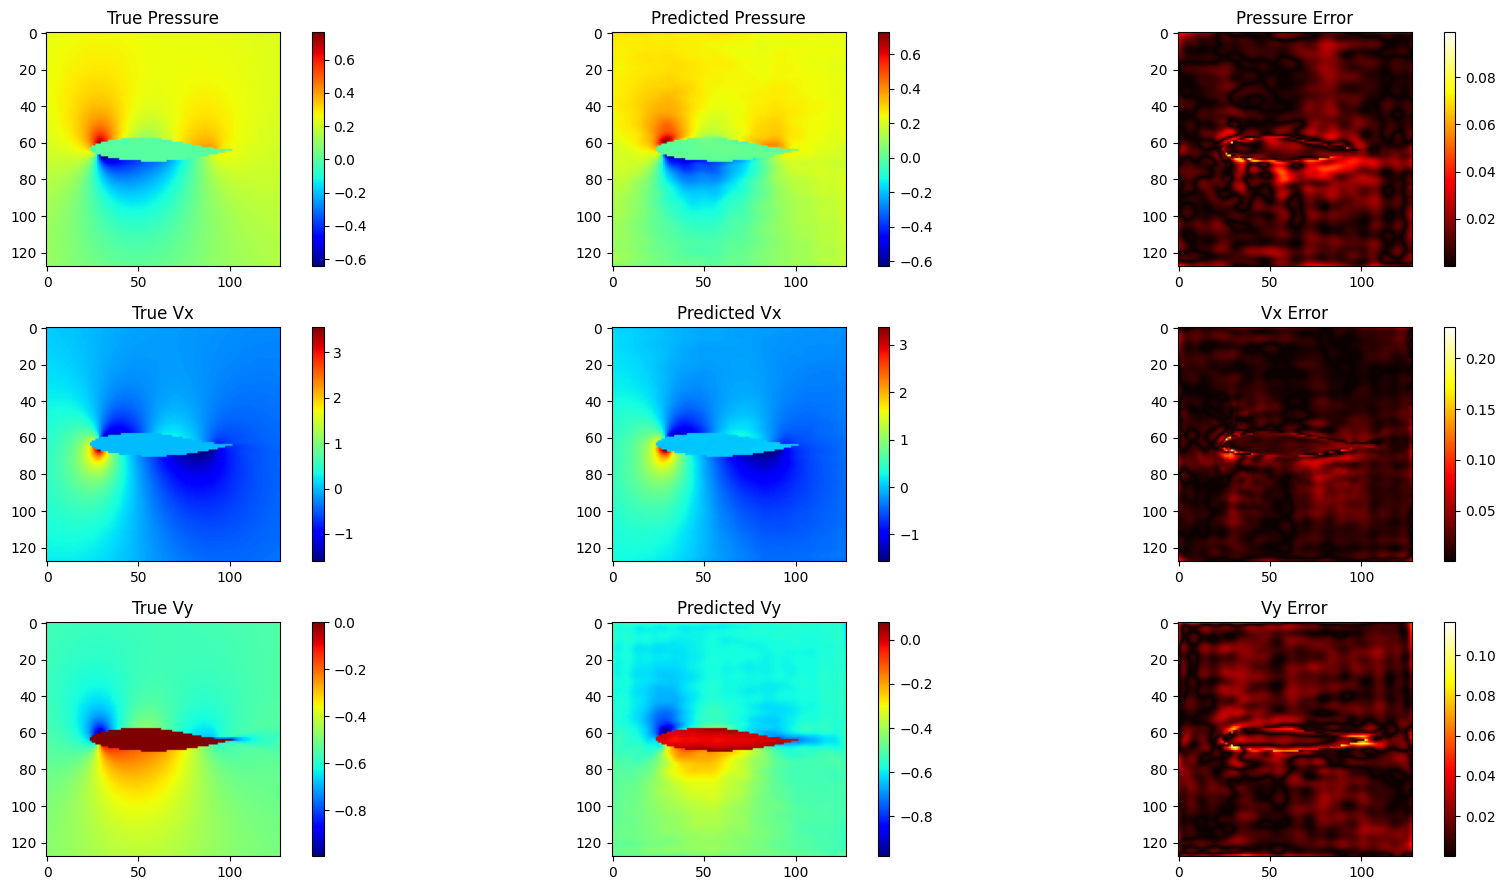

In [60]:
fields = ["Pressure", "Vx", "Vy"]

plt.figure(figsize=(18,9))

i = 7

for c in range(3):
    plt.subplot(3,3,3*c+1)
    plt.title(f"True {fields[c]}")
    plt.imshow(all_targets[i,c].cpu(), cmap='jet')
    plt.colorbar()

    plt.subplot(3,3,3*c+2)
    plt.title(f"Predicted {fields[c]}")
    plt.imshow(all_preds[i,c].cpu(), cmap='jet')
    plt.colorbar()

    plt.subplot(3,3,3*c+3)
    plt.title(f"{fields[c]} Error")
    plt.imshow((all_preds[i,c].cpu() - all_targets[i,c].cpu()).abs(), cmap='hot')
    plt.colorbar()

plt.tight_layout()
plt.show()